In [22]:
import numpy as np, pandas as pd, glob

In [23]:
import os

path = r'C:\Users\palhr\OneDrive\Desktop\Pgdba Projects\RTSM\Data'
print(os.listdir(path))

['AP001.csv', 'AP002.csv', 'AP003.csv', 'AP004.csv', 'AP005.csv', 'AP006.csv', 'AP007.csv', 'AP008.csv', 'AP009.csv', 'AP010.csv', 'AR001.csv', 'AS001.csv', 'AS002.csv', 'AS003.csv', 'AS004.csv', 'AS005.csv', 'AS006.csv', 'AS007.csv', 'AS008.csv', 'AS009.csv', 'BR001.csv', 'BR002.csv', 'BR003.csv', 'BR004.csv', 'BR005.csv', 'BR006.csv', 'BR007.csv', 'BR008.csv', 'BR009.csv', 'BR010.csv', 'BR011.csv', 'BR012.csv', 'BR013.csv', 'BR014.csv', 'BR015.csv', 'BR016.csv', 'BR017.csv', 'BR018.csv', 'BR019.csv', 'BR020.csv', 'BR021.csv', 'BR022.csv', 'BR023.csv', 'BR024.csv', 'BR025.csv', 'BR026.csv', 'BR027.csv', 'BR028.csv', 'BR029.csv', 'BR030.csv', 'BR031.csv', 'BR032.csv', 'BR033.csv', 'BR034.csv', 'BR035.csv', 'CG001.csv', 'CG002.csv', 'CG003.csv', 'CG004.csv', 'CG005.csv', 'CG006.csv', 'CG007.csv', 'CG008.csv', 'CG009.csv', 'CG010.csv', 'CG011.csv', 'CG012.csv', 'CG013.csv', 'CG014.csv', 'CH001.csv', 'CH002.csv', 'CH003.csv', 'DL001.csv', 'DL002.csv', 'DL003.csv', 'DL004.csv', 'DL005.csv'

In [24]:
df_states = pd.read_csv(r'C:\Users\palhr\OneDrive\Desktop\Pgdba Projects\RTSM\Data\stations_info.csv')

In [25]:
df_states.head()

,file_name,state,city,agency,station_location,start_month,start_month_num,start_year
0,AP001,Andhra Pradesh,Tirupati,APPCB,"Tirumala, Tirupati",July,7,2016
1,AP002,Andhra Pradesh,Vijayawada,APPCB,"PWD Grounds, Vijayawada",May,5,2017
2,AP003,Andhra Pradesh,Visakhapatnam,APPCB,"GVM Corporation, Visakhapatnam",July,7,2017
3,AP004,Andhra Pradesh,Rajamahendravaram,APPCB,"Anand Kala Kshetram, Rajamahendravaram",September,9,2017
4,AP005,Andhra Pradesh,Amaravati,APPCB,"Secretariat, Amaravati",November,11,2017


In [26]:
df_states.drop(columns=['agency', 'station_location', 'start_month'], inplace=True)
unique_states = df_states['state'].unique()
unique_states

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Chandigarh', 'Delhi', 'Gujarat',
       'Himachal Pradesh', 'Haryana', 'Jharkhand', 'Jammu and Kashmir',
       'Karnataka', 'Kerala', 'Maharashtra', 'Meghalaya', 'Manipur',
       'Madhya Pradesh', 'Mizoram', 'Nagaland', 'Odisha', 'Punjab',
       'Puducherry', 'Rajasthan', 'Sikkim', 'Telangana', 'Tamil Nadu',
       'Tripura', 'Uttarakhand', 'Uttar Pradesh', 'West Bengal'],
      dtype=object)

In [27]:
def combine_state_df(state_name):
    
    DATASET_SRC = r"C:\Users\palhr\OneDrive\Desktop\Pgdba Projects\RTSM\Data"
    
    state_code = df_states[df_states['state'] == state_name]['file_name'].iloc[0][:2]
    state_files = glob.glob(f'{DATASET_SRC}\\{state_code}*.csv')
    print(f'Combining a total of {len(state_files)} files...\n')

    combined_df = []

    for state_file in state_files:
        
        # ✅ Use os.path.basename instead of manual split — works on ALL OS
        file_name = os.path.basename(state_file).replace('.csv', '').strip()

        match = df_states[df_states['file_name'].str.strip() == file_name]

        if match.empty:
            print(f'⚠️  Skipping {file_name} — not found in df_states')
            continue

        file_df = pd.read_csv(state_file)
        file_df['city'] = match['city'].values[0]
        file_df['city'] = file_df['city'].astype('string')
        combined_df.append(file_df)
        print(f'✅ Loaded {file_name}')

    if not combined_df:
        print("❌ No files loaded — check df_states file_name column")
        return None
        
    return pd.concat(combined_df, ignore_index=True)

In [28]:
df=combine_state_df('West Bengal')
df.info()

Combining a total of 14 files...

✅ Loaded WB001
✅ Loaded WB002
✅ Loaded WB003
✅ Loaded WB004
✅ Loaded WB005
✅ Loaded WB006
✅ Loaded WB007
✅ Loaded WB008
✅ Loaded WB009
✅ Loaded WB010
✅ Loaded WB011
✅ Loaded WB012
✅ Loaded WB013
✅ Loaded WB014
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 635495 entries, 0 to 635494
Data columns (total 36 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   From Date            635495 non-null  object 
 1   To Date              635495 non-null  object 
 2   PM2.5 (ug/m3)        463168 non-null  float64
 3   PM10 (ug/m3)         534764 non-null  float64
 4   NO (ug/m3)           515726 non-null  float64
 5   NO2 (ug/m3)          516386 non-null  float64
 6   NOx (ppb)            475868 non-null  float64
 7   NH3 (ug/m3)          414967 non-null  float64
 8   SO2 (ug/m3)          494849 non-null  float64
 9   CO (mg/m3)           525508 non-null  float64
 10  Ozone (ug/m3)        517328 

In [29]:
df.columns

Index(['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)',
       'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)',
       'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)',
       'Eth-Benzene (ug/m3)', 'MP-Xylene (ug/m3)', 'O Xylene (ug/m3)',
       'WS (m/s)', 'WD (degree)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)',
       'CH4 (ug/m3)', 'AT (degree C)', 'RF (mm)', 'city', 'RH (%)', 'WD (deg)',
       'Temp ()', 'NOx (ug/m3)', 'NH3 ()', 'Temp (degree C)', 'RH ()',
       'BP (W/mt2)', 'SO2 ()', 'SR ()', 'Xylene (ug/m3)'],
      dtype='object')

In [30]:
df.drop(columns = ['From Date','To Date','CH4 (ug/m3)', 'Eth-Benzene (ug/m3)', 'Xylene (ug/m3)'],inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 635495 entries, 0 to 635494
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   PM2.5 (ug/m3)      463168 non-null  float64
 1   PM10 (ug/m3)       534764 non-null  float64
 2   NO (ug/m3)         515726 non-null  float64
 3   NO2 (ug/m3)        516386 non-null  float64
 4   NOx (ppb)          475868 non-null  float64
 5   NH3 (ug/m3)        414967 non-null  float64
 6   SO2 (ug/m3)        494849 non-null  float64
 7   CO (mg/m3)         525508 non-null  float64
 8   Ozone (ug/m3)      517328 non-null  float64
 9   Benzene (ug/m3)    411903 non-null  float64
 10  Toluene (ug/m3)    365328 non-null  float64
 11  MP-Xylene (ug/m3)  360452 non-null  float64
 12  O Xylene (ug/m3)   166287 non-null  float64
 13  WS (m/s)           465780 non-null  float64
 14  WD (degree)        424505 non-null  float64
 15  SR (W/mt2)         413600 non-null  float64
 16  BP

In [32]:
df['wind_direction'] = df['WD (degree)'].fillna(df['WD (deg)'])

In [33]:
cols_to_keep = [
    'PM2.5 (ug/m3)',    # target
    'PM10 (ug/m3)',     # pollutant
    'NO2 (ug/m3)',      # pollutant
    'NOx (ppb)',        # pollutant
    'NH3 (ug/m3)',      # pollutant
    'SO2 (ug/m3)',      # pollutant
    'CO (mg/m3)',       # pollutant
    'Ozone (ug/m3)',    # pollutant
    'WS (m/s)',         # weather
    'wind_direction',   # weather (merged)
    'RH (%)',           # weather
    'SR (W/mt2)',       # weather
    'RF (mm)',          # weather
    'city'              # location
]

df = df[cols_to_keep].copy()

In [34]:
# ── 3. RENAME COLUMNS ────────────────────────────────────────────────
df.columns = [
    'pm25', 'pm10', 'no2', 'nox', 'nh3',
    'so2', 'co', 'ozone', 'wind_speed',
    'wind_direction', 'humidity', 'solar_radiation',
    'rainfall', 'city'
]

In [35]:
# ── 4. DROP ROWS WHERE TARGET IS NULL ────────────────────────────────
before = len(df)
df.dropna(subset=['pm25'], inplace=True)
after = len(df)
print(f"Rows dropped (PM2.5 null) : {before - after}")
print(f"Rows remaining            : {after}")

Rows dropped (PM2.5 null) : 172327
Rows remaining            : 463168


In [36]:
# ── 5. IMPUTE REMAINING NULLS WITH MEDIAN PER CITY ───────────────────
numeric_cols = df.select_dtypes(include='float64').columns

for col in numeric_cols:
    null_before = df[col].isna().sum()
    df[col] = df.groupby('city')[col].transform(
        lambda x: x.fillna(x.median())
    )
    null_after = df[col].isna().sum()
    print(f"{col:20s} → filled {null_before - null_after} nulls")

pm25                 → filled 0 nulls
pm10                 → filled 5059 nulls
no2                  → filled 18989 nulls
nox                  → filled 61355 nulls
nh3                  → filled 62666 nulls
so2                  → filled 4294 nulls
co                   → filled 16971 nulls
ozone                → filled 24444 nulls
wind_speed           → filled 14831 nulls
wind_direction       → filled 14387 nulls
humidity             → filled 8276 nulls
solar_radiation      → filled 29681 nulls
rainfall             → filled 153187 nulls


In [37]:
# ── 6. HANDLE ANY REMAINING NULLS (global median fallback) ───────────
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# ── 7. REMOVE OUTLIERS FROM PM2.5 ───────────────────────────────────
# AQI > 500 is instrument error
before = len(df)
df = df[df['pm25'] <= 500]
df = df[df['pm25'] >= 0]
print(f"\nOutlier rows removed : {before - len(df)}")


Outlier rows removed : 148


In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])
print(f"\nCities encoded : {dict(zip(le.classes_, le.transform(le.classes_)))}")


Cities encoded : {'Asansol': np.int64(0), 'Durgapur': np.int64(1), 'Haldia': np.int64(2), 'Howrah': np.int64(3), 'Kolkata': np.int64(4), 'Siliguri': np.int64(5)}


In [ ]:
# ── LOG-TRANSFORM SKEWED FEATURES ────────────────────────────────────
import numpy as np

# Features that are counts/concentrations — typically right-skewed
log_features = ['pm10', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone', 
                'wind_speed', 'rainfall', 'solar_radiation']

print("Skewness BEFORE log transform:")
for col in log_features:
    print(f"  {col:20s}: {df[col].skew():.2f}")

# Apply log1p (handles zeros safely)
for col in log_features:
    df[f'{col}_log'] = np.log1p(df[col])

# Update FEATURES list to use log-transformed versions
FEATURES = [
    'pm10_log', 'no2_log', 'nox_log', 'nh3_log', 'so2_log', 
    'co_log', 'ozone_log', 'wind_speed_log', 'wind_direction',  # direction is circular, skip
    'humidity', 'solar_radiation_log', 'rainfall_log', 'city_encoded'
]

print("\nSkewness AFTER log transform:")
for col in log_features:
    print(f"  {col:20s}: {df[col + '_log'].skew():.2f}")

# ── TARGET (already log-transformed if skewed) ───────────────────────
skewness = df['pm25'].skew()
print(f"\nPM2.5 Skewness : {skewness:.2f}")
df['pm25_log'] = np.log1p(df['pm25'])
TARGET = 'pm25_log'
print(f"✅ Target: {TARGET}")

X = df[FEATURES]
y = df[TARGET]

print(f"\nFinal Shape : {df.shape}")
print(f"Nulls       : {X.isnull().sum().sum()}")

# ── 10. FINAL FEATURE MATRIX ─────────────────────────────────────────
FEATURES = [
    'pm10', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone',
    'wind_speed', 'wind_direction', 'humidity',
    'solar_radiation', 'rainfall', 'city_encoded'
]

X = df[FEATURES]
y = df[TARGET]

# ── 11. VERIFY ───────────────────────────────────────────────────────
print(f"\n{'─'*40}")
print(f"Final Shape     : {df.shape}")
print(f"Features        : {len(FEATURES)}")
print(f"Target          : {TARGET}")
print(f"Nulls remaining : {X.isnull().sum().sum()}")
print(f"{'─'*40}")
print(f"\n✅ Data ready for modelling!")
print(X.describe().round(2))


PM2.5 Skewness : 1.92
✅ Using log-transformed PM2.5 as target

────────────────────────────────────────
Final Shape     : (463020, 16)
Features        : 13
Target          : pm25_log
Nulls remaining : 0
────────────────────────────────────────

✅ Data ready for modelling!
            pm10        no2        nox        nh3        so2         co  \
count  463020.00  463020.00  463020.00  463020.00  463020.00  463020.00   
mean      114.98      28.22      42.29      20.22      11.65       0.74   
std        95.19      25.93      47.58      18.57      12.67       0.61   
min         0.10       0.01       0.00       0.01       0.01       0.00   
25%        44.75      12.36      19.79      10.65       5.23       0.36   
50%        85.80      19.70      28.34      15.40       8.30       0.57   
75%       159.88      34.77      44.18      25.01      13.61       0.88   
max       999.99     460.08     499.30     499.28     199.63       9.97   

           ozone  wind_speed  wind_direction   hum

Train size : (370416, 13)
Test size  : (92604, 13)

════════════════════════════════════════════════════════════
               OLS REGRESSION
════════════════════════════════════════════════════════════
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                 7.211e+04
Date:                Sun, 29 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:21:15   Log-Likelihood:            -2.4879e+05
No. Observations:              370416   AIC:                         4.976e+05
Df Residuals:                  370402   BIC:                         4.978e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
      

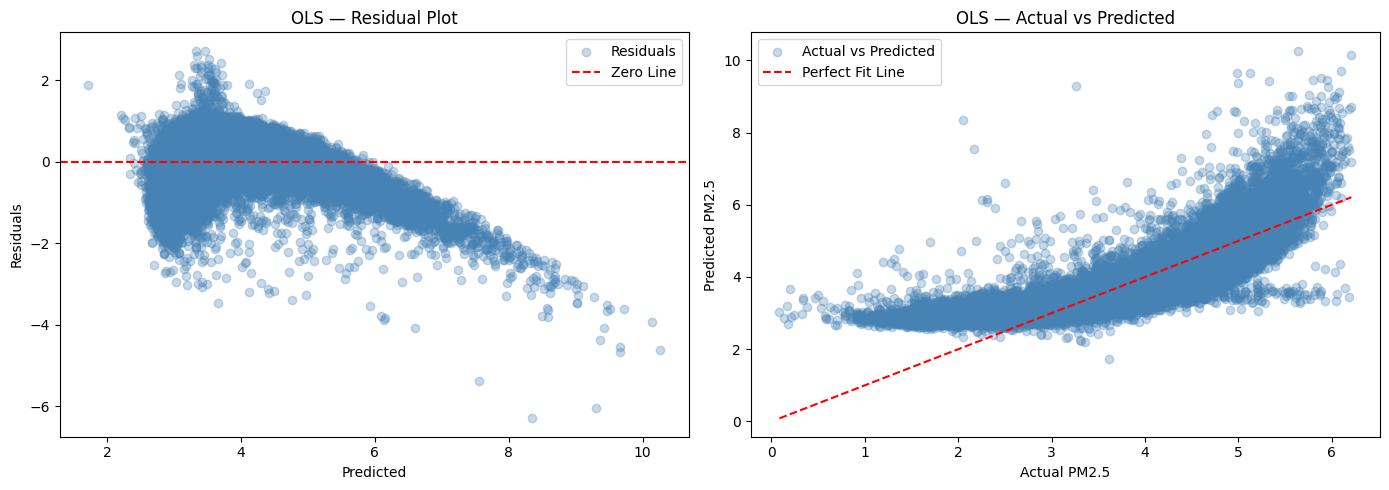


════════════════════════════════════════════════════════════
               LIGHTGBM
════════════════════════════════════════════════════════════
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.285016
[200]	valid_0's rmse: 0.274687
[300]	valid_0's rmse: 0.270201
[400]	valid_0's rmse: 0.26712
[500]	valid_0's rmse: 0.264864
[600]	valid_0's rmse: 0.263161
[700]	valid_0's rmse: 0.261628
[800]	valid_0's rmse: 0.260345
[900]	valid_0's rmse: 0.25913
[1000]	valid_0's rmse: 0.25796
Did not meet early stopping. Best iteration is:
[1000]	valid_0's rmse: 0.25796

LightGBM Test RMSE : 0.2580
LightGBM Test MAE  : 0.1815
LightGBM Test R²   : 0.9160


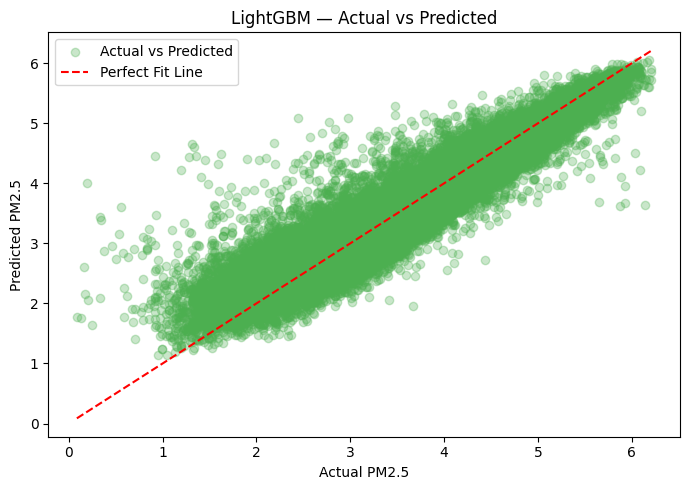


════════════════════════════════════════════════════════════
               XGBOOST
════════════════════════════════════════════════════════════
[0]	validation_0-rmse:3.17063
[100]	validation_0-rmse:0.29207
[200]	validation_0-rmse:0.28174
[300]	validation_0-rmse:0.27743
[400]	validation_0-rmse:0.27448
[500]	validation_0-rmse:0.27219
[600]	validation_0-rmse:0.27043
[700]	validation_0-rmse:0.26876
[800]	validation_0-rmse:0.26735
[900]	validation_0-rmse:0.26611
[999]	validation_0-rmse:0.26526

XGBoost Test RMSE : 0.2653
XGBoost Test MAE  : 0.1869
XGBoost Test R²   : 0.9112


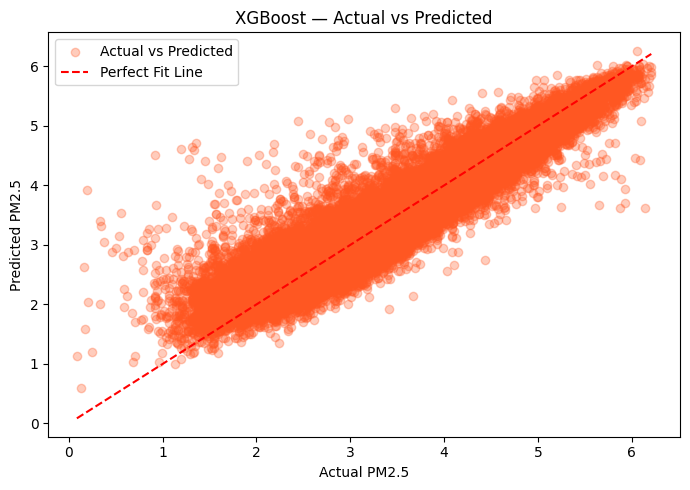

92604 13

══════════════════════════════════════════════════════════════════════
                    FINAL MODEL COMPARISON
══════════════════════════════════════════════════════════════════════
   Model   RMSE    MAE     R²  Adjusted R²  Rank
LightGBM 0.2580 0.1815 0.9160       0.9160     1
 XGBoost 0.2653 0.1869 0.9112       0.9112     2
     OLS 0.4710 0.3500 0.7199       0.7199     3
══════════════════════════════════════════════════════════════════════


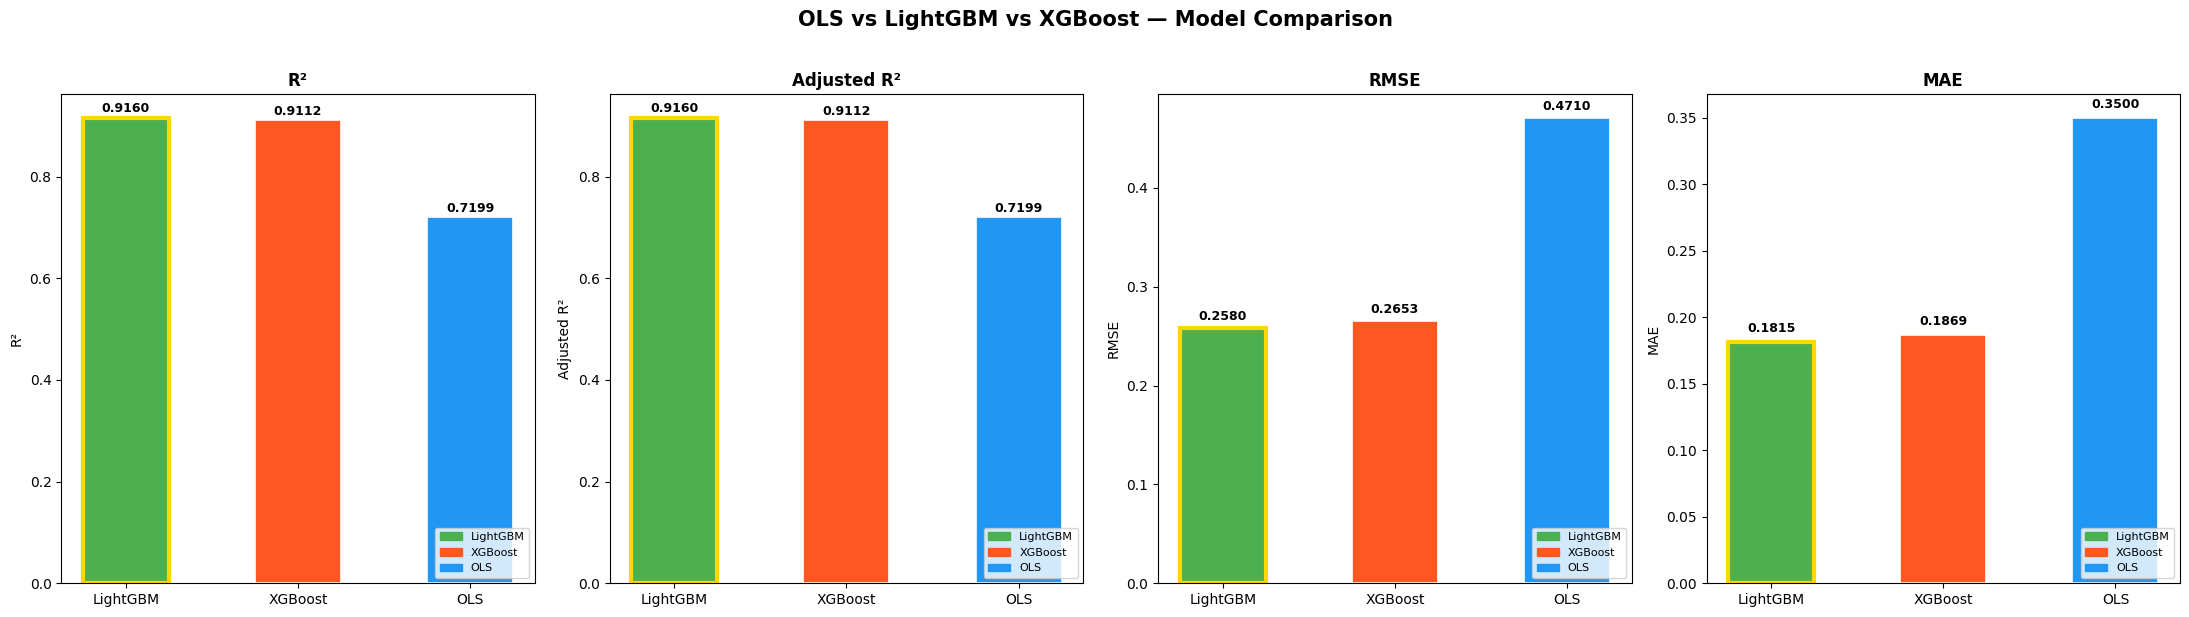

✅ Comparison plot saved → model_comparison.png


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import lightgbm as lgb
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════
# 1. TRAIN TEST SPLIT
# ══════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

# ══════════════════════════════════════════════════════════════════════
# 2. SCALING (Only for OLS)
# ══════════════════════════════════════════════════════════════════════
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

# ══════════════════════════════════════════════════════════════════════
# 3. OLS REGRESSION
# ══════════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("               OLS REGRESSION")
print("═"*60)

X_train_ols = sm.add_constant(X_train_scaled)
X_test_ols  = sm.add_constant(X_test_scaled)

# ✅ .values fixes index alignment error
ols_model = sm.OLS(y_train.values, X_train_ols).fit()
print(ols_model.summary())

y_pred_ols = ols_model.predict(X_test_ols)

ols_rmse = np.sqrt(mean_squared_error(y_test.values, y_pred_ols))
ols_mae  = mean_absolute_error(y_test.values, y_pred_ols)
ols_r2   = r2_score(y_test.values, y_pred_ols)

print(f"\nOLS Test RMSE : {ols_rmse:.4f}")
print(f"OLS Test MAE  : {ols_mae:.4f}")
print(f"OLS Test R²   : {ols_r2:.4f}")

# ── VIF Check ─────────────────────────────────────────────────────────
print("\n── VIF Scores ──")
vif_df            = pd.DataFrame()
vif_df['Feature'] = X_train_scaled.columns
vif_df['VIF']     = [variance_inflation_factor(X_train_scaled.values, i)
                     for i in range(X_train_scaled.shape[1])]
vif_df = vif_df.sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))
print("⚠️  VIF > 10 means multicollinearity problem")

# ── OLS Residual + Actual vs Predicted Plots ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_ols, y_test.values - y_pred_ols,
                alpha=0.3, color='steelblue', label='Residuals')
axes[0].axhline(0, color='red', linestyle='--', label='Zero Line')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")
axes[0].set_title("OLS — Residual Plot")
axes[0].legend()

axes[1].scatter(y_test.values, y_pred_ols,
                alpha=0.3, color='steelblue', label='Actual vs Predicted')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', label='Perfect Fit Line')
axes[1].set_xlabel("Actual PM2.5")
axes[1].set_ylabel("Predicted PM2.5")
axes[1].set_title("OLS — Actual vs Predicted")
axes[1].legend()

plt.tight_layout()
plt.savefig("ols_plots.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 4. LIGHTGBM
# ══════════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("               LIGHTGBM")
print("═"*60)

lgb_params = {
    "objective":         "regression",
    "metric":            "rmse",
    "learning_rate":     0.05,
    "num_leaves":        63,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "min_child_samples": 20,
    "lambda_l1":         0.1,
    "lambda_l2":         0.1,
    "verbose":           -1,
}

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round = 1000,
    valid_sets      = [lgb_val],
    callbacks       = [lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred_lgb = lgb_model.predict(X_test)

lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
lgb_mae  = mean_absolute_error(y_test, y_pred_lgb)
lgb_r2   = r2_score(y_test, y_pred_lgb)

print(f"\nLightGBM Test RMSE : {lgb_rmse:.4f}")
print(f"LightGBM Test MAE  : {lgb_mae:.4f}")
print(f"LightGBM Test R²   : {lgb_r2:.4f}")

# ── LightGBM Actual vs Predicted Plot ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_lgb, alpha=0.3, color='#4CAF50', label='Actual vs Predicted')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', label='Perfect Fit Line')
ax.set_xlabel("Actual PM2.5")
ax.set_ylabel("Predicted PM2.5")
ax.set_title("LightGBM — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.savefig("lgb_actual_vs_predicted.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 5. XGBOOST
# ══════════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("               XGBOOST")
print("═"*60)

xgb_model = xgb.XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 0.1,
    early_stopping_rounds = 50,
    eval_metric           = "rmse",
    random_state          = 42,
    verbosity             = 1
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 100
)

y_pred_xgb = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2   = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Test RMSE : {xgb_rmse:.4f}")
print(f"XGBoost Test MAE  : {xgb_mae:.4f}")
print(f"XGBoost Test R²   : {xgb_r2:.4f}")

# ── XGBoost Actual vs Predicted Plot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred_xgb, alpha=0.3, color='#FF5722', label='Actual vs Predicted')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', label='Perfect Fit Line')
ax.set_xlabel("Actual PM2.5")
ax.set_ylabel("Predicted PM2.5")
ax.set_title("XGBoost — Actual vs Predicted")
ax.legend()
plt.tight_layout()
plt.savefig("xgb_actual_vs_predicted.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════
# 6. ADJUSTED R² FUNCTION
# ══════════════════════════════════════════════════════════════════════
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n_test = X_test.shape[0]
k      = X_test.shape[1]

print(n_test,k)
ols_adj_r2 = adjusted_r2(ols_r2, n_test, k)
lgb_adj_r2 = adjusted_r2(lgb_r2, n_test, k)
xgb_adj_r2 = adjusted_r2(xgb_r2, n_test, k)

# ══════════════════════════════════════════════════════════════════════
# 7. FINAL COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════
results = pd.DataFrame({
    "Model"       : ["OLS", "LightGBM", "XGBoost"],
    "RMSE"        : [ols_rmse,    lgb_rmse,    xgb_rmse],
    "MAE"         : [ols_mae,     lgb_mae,     xgb_mae],
    "R²"          : [ols_r2,      lgb_r2,      xgb_r2],
    "Adjusted R²" : [ols_adj_r2,  lgb_adj_r2,  xgb_adj_r2]
})
results = results.sort_values("R²", ascending=False).reset_index(drop=True)
results["Rank"] = results.index + 1

results_display = results.copy()
results_display[["RMSE","MAE","R²","Adjusted R²"]] = \
    results_display[["RMSE","MAE","R²","Adjusted R²"]].round(4)

print("\n" + "═"*70)
print("                    FINAL MODEL COMPARISON")
print("═"*70)
print(results_display.to_string(index=False))
print("═"*70)

# ══════════════════════════════════════════════════════════════════════
# 8. COMPARISON BAR CHARTS WITH LEGENDS
# ══════════════════════════════════════════════════════════════════════
metrics = ["R²", "Adjusted R²", "RMSE", "MAE"]
colors  = {
    "OLS"      : "#2196F3",
    "LightGBM" : "#4CAF50",
    "XGBoost"  : "#FF5722"
}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("OLS vs LightGBM vs XGBoost — Model Comparison",
             fontsize=15, fontweight='bold', y=1.02)

models = results["Model"].tolist()

for ax, metric in zip(axes, metrics):
    values = results[metric].tolist()
    bars   = ax.bar(
        models, values,
        color     = [colors[m] for m in models],
        width     = 0.5,
        edgecolor = 'white',
        linewidth = 1.2
    )

    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    # Legend
    legend_patches = [
        plt.Rectangle((0,0), 1, 1, color=colors[m], label=m)
        for m in models
    ]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, fontsize=10)

    # Gold border on best bar
    if metric in ["R²", "Adjusted R²"]:
        best_idx = values.index(max(values))
    else:
        best_idx = values.index(min(values))

    ax.patches[best_idx].set_edgecolor('gold')
    ax.patches[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved → model_comparison.png")



In [42]:
import matplotlib
matplotlib.use('Agg')   # ✅ add this at the top of your file if plots don't show

# ── SHAP on a sample ─────────────────────────────────────────────────
shap_sample = X_test.sample(n=7000, random_state=42)

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

# Summary dot plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample,
                  feature_names=FEATURES,
                  show=False)            # ✅ show=False lets matplotlib handle it
plt.title('SHAP Summary — LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()                              # ✅ close before next plot
print('✅ Saved → shap_summary.png')

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample,
                  feature_names=FEATURES,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — LightGBM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.close()                              # ✅ close after saving
print('✅ Saved → shap_bar.png')

✅ Saved → shap_summary.png
✅ Saved → shap_bar.png
